# Notebook 2: Collecting Activations

**Goal:** Look inside the model while it processes harmful vs harmless prompts, and capture its internal states (activations) at every layer.

**Why?** If refusal is encoded as a "direction" in the model's internal representations, we need to capture those representations to find it.

## Quick Concept: The Residual Stream

Think of a transformer like a factory assembly line:

```
Input tokens → [Embedding] → [Block 1] → [Block 2] → ... → [Block N] → Output
                    ↓            ↓            ↓                  ↓
              residual stream flows through all blocks →→→→→→→→→→→
```

The **residual stream** is like a conveyor belt that carries information through the model:
- Each block (attention + MLP) **reads** from the belt, does some processing, and **writes its result back** onto the belt
- The final state of the belt determines what the model outputs

**Key insight:** If refusal is a "direction" in this stream, we can find it by comparing what's on the belt when processing harmful vs harmless prompts.

## Quick Concept: Vectors & Directions

A **vector** is just a list of numbers: `[3.2, -1.5, 0.8]`

A **direction** is where that vector points. Two vectors can point in the same direction even if they have different lengths:
- `[2, 4]` and `[1, 2]` point the same way (both point "2 units right for every 1 unit up")

In an LLM, each token's activation at each layer is a vector with hundreds of dimensions. A "refusal direction" means there's a specific way these numbers tend to align when the model is about to refuse.

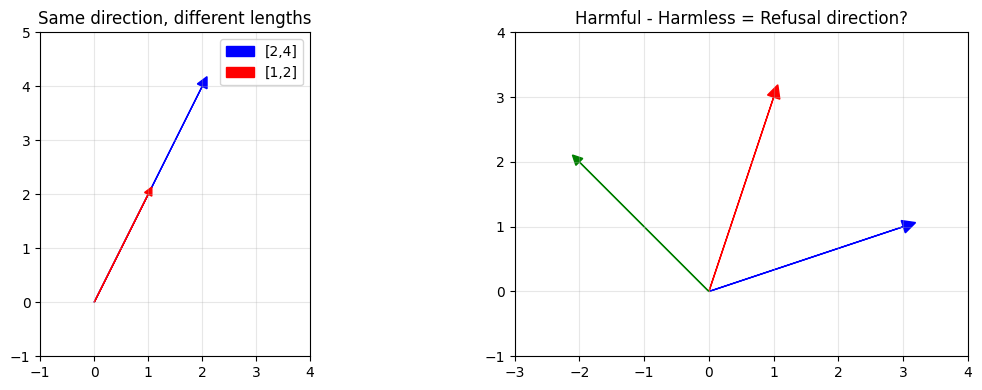

The idea: if we subtract 'harmless activations' from 'harmful activations',
what's left should be the 'refusal' component!


In [8]:
# Quick visual: vectors and directions in 2D
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: Two vectors pointing in the same direction
ax = axes[0]
ax.arrow(0, 0, 2, 4, head_width=0.2, head_length=0.2, fc='blue', ec='blue')
ax.arrow(0, 0, 1, 2, head_width=0.15, head_length=0.15, fc='red', ec='red')
ax.set_xlim(-1, 4)
ax.set_ylim(-1, 5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title("Same direction, different lengths")
ax.legend(["[2,4]", "[1,2]"])

# Right: Two vectors pointing in different directions
ax = axes[1]
ax.arrow(0, 0, 3, 1, head_width=0.2, head_length=0.2, fc='blue', ec='blue', label='harmless')
ax.arrow(0, 0, 1, 3, head_width=0.2, head_length=0.2, fc='red', ec='red', label='harmful')
ax.arrow(0, 0, -2, 2, head_width=0.15, head_length=0.15, fc='green', ec='green', label='difference')
ax.set_xlim(-3, 4)
ax.set_ylim(-1, 4)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.set_title("Harmful - Harmless = Refusal direction?")

plt.tight_layout()
plt.show()
print("The idea: if we subtract 'harmless activations' from 'harmful activations',")
print("what's left should be the 'refusal' component!")

## Step 1: Load Model with TransformerLens

We use **TransformerLens** instead of plain HuggingFace because it gives us easy access to internal activations via "hooks" — functions that run at specific points during the model's forward pass and let us capture or modify the data flowing through.

In [9]:
import torch
import json
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from transformer_lens import HookedTransformer

# Disable gradients to save memory
torch.set_grad_enabled(False)

# Load our prepared data from notebook 1
with open("data/prepared_instructions.json", "r") as f:
    data = json.load(f)

MODEL_NAME = data["model_name"]
harmless_instructions = data["harmless_instructions"]
harmful_instructions = data["harmful_instructions"]
print(f"Loaded {len(harmless_instructions)} harmless + {len(harmful_instructions)} harmful instructions")
print(f"Model: {MODEL_NAME}")

Loaded 256 harmless + 256 harmful instructions
Model: Qwen/Qwen2-0.5B-Instruct


In [12]:
# Load the model using TransformerLens's HookedTransformer
# This wraps the model with hooks at every layer so we can capture activations.
#
# Compatibility fix: some transformers builds for Qwen2 omit `rope_theta`,
# but TransformerLens expects it when converting HF config.
from transformers.models.qwen2.configuration_qwen2 import Qwen2Config

if not hasattr(Qwen2Config, "rope_theta"):
    Qwen2Config.rope_theta = 1_000_000.0

print("Loading model with TransformerLens (this takes a minute)...")
hooked_model = HookedTransformer.from_pretrained(
    MODEL_NAME,
    dtype=torch.float32,
    device="cpu",  # Keep CPU for stability on this setup
    trust_remote_code=True,
)

print(f"\nModel loaded!")
print(f"  Layers: {hooked_model.cfg.n_layers}")
print(f"  Hidden size (d_model): {hooked_model.cfg.d_model}")
print(f"  Attention heads: {hooked_model.cfg.n_heads}")
print(f"  Vocabulary size: {hooked_model.cfg.d_vocab}")

Loading model with TransformerLens (this takes a minute)...


Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

TypeError: transformer_lens.loading_from_pretrained.get_pretrained_model_config() got multiple values for keyword argument 'hf_cfg'

## Step 2: Understand Hook Points

TransformerLens names every point in the model where we can capture data. The ones we care about are the **residual stream** activations — captured at three positions in each block:

- `blocks.{i}.hook_resid_pre` — residual stream **before** the attention layer
- `blocks.{i}.hook_resid_mid` — **between** attention and MLP
- `blocks.{i}.hook_resid_post` — **after** the MLP layer

Let's see all available hook points:

In [ ]:
# List all hook points that contain "resid" — these are the residual stream hooks
resid_hooks = [name for name, _ in hooked_model.hook_dict.items() if "resid" in name]
print(f"Found {len(resid_hooks)} residual stream hook points:\n")
for hook in resid_hooks:
    print(f"  {hook}")

## Step 3: Collect Activations

Now we'll run both sets of instructions through the model and capture the residual stream activations.

**Important:** We only capture the activation at the **last token position**. Why? Because in autoregressive models (like this one), the last token position is where the model "decides" what to generate next — including whether to refuse or comply.

In [ ]:
def collect_activations(model, instructions, batch_size=8):
    """
    Run instructions through the model and collect residual stream activations
    at the last token position for each layer.
    
    Returns: dict mapping hook_name -> tensor of shape (n_samples, d_model)
    """
    # We'll collect activations for all resid_pre hooks (one per layer)
    # resid_pre captures the state BEFORE each block processes it
    hook_names = [f"blocks.{i}.hook_resid_pre" for i in range(model.cfg.n_layers)]
    
    # Storage: one list per hook, will collect activations across batches
    all_activations = {name: [] for name in hook_names}
    
    # Process in batches to fit in memory
    for batch_start in tqdm(range(0, len(instructions), batch_size), desc="Collecting"):
        batch = instructions[batch_start:batch_start + batch_size]
        
        # Tokenize the batch
        tokens = model.to_tokens(batch, prepend_bos=False)
        
        # Run through the model, capturing activations at all hook points
        # names_filter tells it to only save the hooks we care about (saves memory)
        _, cache = model.run_with_cache(
            tokens,
            names_filter=lambda name: name in hook_names
        )
        
        # Extract the LAST token's activation for each hook
        for name in hook_names:
            # cache[name] shape: (batch_size, seq_len, d_model)
            # We want the last token: [:, -1, :] → (batch_size, d_model)
            last_token_act = cache[name][:, -1, :].cpu()
            all_activations[name].append(last_token_act)
        
        # Free memory
        del cache
    
    # Concatenate all batches: (n_samples, d_model)
    for name in hook_names:
        all_activations[name] = torch.cat(all_activations[name], dim=0)
    
    return all_activations

In [ ]:
# Collect activations for HARMLESS instructions
print("Collecting activations for HARMLESS instructions...")
harmless_activations = collect_activations(hooked_model, harmless_instructions, batch_size=8)

# Check shapes
first_hook = list(harmless_activations.keys())[0]
print(f"\nShape per layer: {harmless_activations[first_hook].shape}")
print(f"  → {harmless_activations[first_hook].shape[0]} samples, {harmless_activations[first_hook].shape[1]} dimensions per activation")

In [ ]:
# Collect activations for HARMFUL instructions
print("Collecting activations for HARMFUL instructions...")
harmful_activations = collect_activations(hooked_model, harmful_instructions, batch_size=8)

print(f"\nDone! Collected activations at {len(harmful_activations)} layers for both datasets.")

## Step 4: Visualize — Do Harmful and Harmless Activations Differ?

Let's see if the model's internal states look different when processing harmful vs harmless prompts. If they do, there's hope we can find a "refusal direction".

In [ ]:
# Plot the mean activation NORM (length of the vector) per layer for both types
n_layers = hooked_model.cfg.n_layers
layers = list(range(n_layers))

harmless_norms = []
harmful_norms = []

for i in layers:
    hook_name = f"blocks.{i}.hook_resid_pre"
    # Compute the average vector length (norm) across all samples
    harmless_norms.append(harmless_activations[hook_name].float().norm(dim=-1).mean().item())
    harmful_norms.append(harmful_activations[hook_name].float().norm(dim=-1).mean().item())

plt.figure(figsize=(12, 5))
plt.plot(layers, harmless_norms, 'b-o', label='Harmless', markersize=4)
plt.plot(layers, harmful_norms, 'r-o', label='Harmful', markersize=4)
plt.xlabel('Layer')
plt.ylabel('Mean Activation Norm')
plt.title('Activation Norms: Harmful vs Harmless (per layer)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("If the lines diverge at certain layers, those layers might encode refusal behavior.")

## Step 5: Save Activations for Next Notebook

In [ ]:
import os
os.makedirs("data", exist_ok=True)

# Save activations as torch tensors
torch.save(harmless_activations, "data/harmless_activations.pt")
torch.save(harmful_activations, "data/harmful_activations.pt")

# Save model config info we'll need later
model_info = {
    "model_name": MODEL_NAME,
    "n_layers": hooked_model.cfg.n_layers,
    "d_model": hooked_model.cfg.d_model,
    "n_heads": hooked_model.cfg.n_heads,
}
with open("data/model_info.json", "w") as f:
    json.dump(model_info, f)

print(f"Saved activations to data/")
print(f"  harmless_activations.pt: {os.path.getsize('data/harmless_activations.pt') / 1e6:.1f} MB")
print(f"  harmful_activations.pt: {os.path.getsize('data/harmful_activations.pt') / 1e6:.1f} MB")

## Summary

In this notebook we:
1. Learned about the **residual stream** — the conveyor belt carrying info through transformer layers
2. Loaded the model with **TransformerLens** to get access to internal activations
3. Collected **last-token activations** at every layer for 256 harmless + 256 harmful prompts
4. Visualized the difference in activation norms

**Next → Notebook 03:** We'll compute the actual "refusal direction" by taking the mean difference between harmful and harmless activations at each layer.

---

**Try it yourself:** What happens if you look at activations from the FIRST token position instead of the last? Change `[:, -1, :]` to `[:, 0, :]` in the collect function and see if the difference pattern changes. (The first token shouldn't know about refusal yet!)